# Deep Dream

**Credit:** This code is adapted from the Keras example [Deep Dream](https://keras.io/examples/generative/deep_dream/) by [fchollet](https://twitter.com/fchollet). It has been modified so that changes to the settings always take effect, to keep pixel values in range, to add random jitter against grid artifacts, and to compare the effect of different layers side by side.

Runs best on a GPU runtime.

## Introduction

"Deep dream" is an image-filtering technique which consists of taking an image classification model, and running gradient ascent over an input image to try to maximize the activations of specific layers (and sometimes, specific units in specific layers) for this input. It produces hallucination-like visuals.

It was first introduced by Alexander Mordvintsev from Google in July 2015.

Process:

- Load the original image.
- Define a number of processing scales ("octaves"), from smallest to largest.
- Resize the original image to the smallest scale.
- For every scale, starting with the smallest (i.e. current one):
    - Run gradient ascent
    - Upscale image to the next scale
    - Reinject the detail that was lost at upscaling time
- Stop when we are back to the original size.

To obtain the detail lost during upscaling, we simply take the original image, shrink it down, upscale it, and compare the result to the (resized) original image.

## Setup

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import math
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import keras
from keras.applications import inception_v3

## Choose an image

By default we dream on a photo of the sky. To use your own photo, set `IMAGE_PATH` to a local file, or in Colab set `UPLOAD_IMAGE = True` to pick one from your computer.

Large photos are downscaled so that their longest side is at most `MAX_DIM` pixels. Dreaming on a full-resolution phone photo is very slow and can run out of GPU memory.

In [2]:
IMAGE_PATH = None  # Path to your own image, or None for the default sky photo
UPLOAD_IMAGE = False  # Colab only: pick an image from your computer
MAX_DIM = 1024  # Longest side of the image we dream on, in pixels

imgur rejects downloads that use Python's default User-Agent (HTTP 429), so `keras.utils.get_file` can't fetch the default image. We download it with a browser User-Agent instead, and cache it with Keras's other downloads.

In [3]:
def download_image(url, fname):
    path = os.path.join(os.path.expanduser("~"), ".keras", "datasets", fname)
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(path, "wb") as f:
            f.write(response.read())
    return path


if UPLOAD_IMAGE:
    from google.colab import files

    IMAGE_PATH = next(iter(files.upload()))
elif IMAGE_PATH is None:
    IMAGE_PATH = download_image("https://i.imgur.com/aGBdQyK.jpg", "sky.jpg")

image_name = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

## Dream settings

These are the names of the layers for which we try to maximize activation, as well as their weight in the final loss we try to maximize. You can tweak these settings to obtain new visual effects.

In [4]:
layer_settings = {
    "mixed4": 1.0,
    "mixed5": 1.5,
    "mixed6": 2.0,
    "mixed7": 2.5,
}

Playing with these hyperparameters will also allow you to achieve new effects.

Compared with the original example (3 octaves, 1.4 apart), we use 5 octaves 1.3 apart. The first octave then starts at about a third of the original size instead of half, so the patterns come out larger.

In [5]:
dream_settings = {
    "step": 0.01,  # Gradient ascent step size
    "num_octave": 5,  # Number of scales at which to run gradient ascent
    "octave_scale": 1.3,  # Size ratio between scales
    "iterations": 20,  # Number of ascent steps per scale
    "max_loss": 15.0,  # Stop an octave early once the loss passes this
    "jitter": 32,  # Max random shift per step, in pixels
}

Let's set up some image preprocessing/deprocessing utilities:

In [6]:
def preprocess_image(image_path, max_dim=None):
    # Util function to open, downscale and format pictures
    # into appropriate arrays.
    img = keras.utils.load_img(image_path)
    if max_dim is not None:
        img.thumbnail((max_dim, max_dim))  # Only ever shrinks, keeps aspect ratio
    img = keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = inception_v3.preprocess_input(img)
    return img

In [7]:
def deprocess_image(x):
    # Util function to convert a batch of one image into a valid image.
    x = np.asarray(x)[0]
    # Undo inception v3 preprocessing (without modifying the input in place)
    x = (x / 2.0 + 0.5) * 255.0
    # Convert to uint8 and clip to the valid range [0, 255]
    return np.clip(x, 0, 255).astype("uint8")

In [8]:
def show_images(images, titles, cols=None):
    # Display preprocessed images in a grid, each with its title.
    cols = cols or len(images)
    rows = math.ceil(len(images) / cols)
    height, width = images[0].shape[1:3]
    col_width = min(6 * cols, 16) / cols
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(col_width * cols, rows * (col_width * height / width + 0.4)),
        squeeze=False,
    )
    for ax in axes.flat:
        ax.axis("off")
    for ax, image, title in zip(axes.flat, images, titles):
        ax.imshow(deprocess_image(image))
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


def result_filename(image_name, layer_settings, dream_settings):
    # Name each result after its settings so runs don't overwrite each other.
    layers = "_".join(f"{name}-{weight:g}" for name, weight in layer_settings.items())
    return (
        f"{image_name}_{layers}"
        f"_step{dream_settings['step']:g}_oct{dream_settings['num_octave']}.png"
    )

This is our base image:

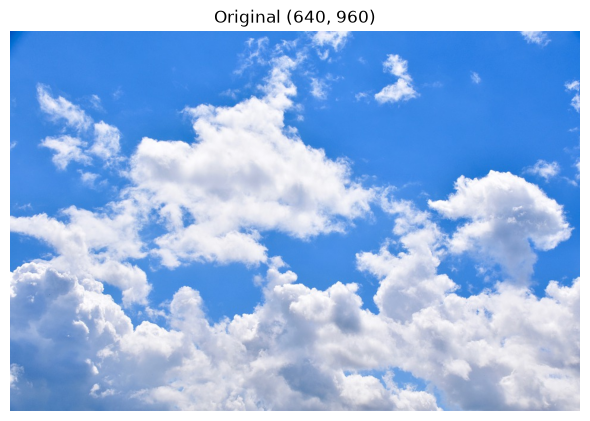

In [9]:
original_img = preprocess_image(IMAGE_PATH, max_dim=MAX_DIM)
show_images([original_img], [f"Original {original_img.shape[1:3]}"])

## Compute the Deep Dream loss

First, build a feature extraction model to retrieve the activations of our target layers given an input image.

Build an InceptionV3 model loaded with pre-trained ImageNet weights:

In [10]:
model = inception_v3.InceptionV3(weights="imagenet", include_top=False)

`make_dream_step()` builds the feature extractor, the loss and the gradient ascent step together, for one set of layer settings.

This matters because `@tf.function` traces the step once per image size, and bakes the model and the layer weights into that trace. In the original example the step read `layer_settings` and the feature extractor from global variables. After editing the settings and re-running the octave loop, it silently kept using the old ones. Building a fresh step for every dream means your changes always take effect.

Two additions make the images cleaner:

- **Random jitter:** before each step, the image is shifted by a random offset of up to `jitter` pixels, and shifted back after the update. This stops the network's stride grid from imprinting itself on the image. The trick comes from the original DeepDream implementation.
- **Clipping:** after each update, pixel values are clipped to [-1, 1], the range InceptionV3 expects. Without it, values drift out of range (up to 2.1 on the sky image) and get flattened to pure white or black when the image is saved.

In [11]:
def make_dream_step(layer_settings, jitter):
    # Set up a model that returns the activation values for every target layer
    # (as a dict)
    feature_extractor = keras.Model(
        inputs=model.inputs,
        outputs={name: model.get_layer(name).output for name in layer_settings},
    )

    def compute_loss(input_image):
        features = feature_extractor(input_image)
        # Initialize the loss
        loss = tf.zeros(shape=())
        for name, activation in features.items():
            coeff = layer_settings[name]
            # We avoid border artifacts by only involving non-border pixels in the loss.
            scaling = tf.reduce_prod(tf.cast(tf.shape(activation), "float32"))
            loss += coeff * tf.reduce_sum(tf.square(activation[:, 2:-2, 2:-2, :])) / scaling
        return loss

    @tf.function(reduce_retracing=True)
    def gradient_ascent_step(img, learning_rate):
        # Randomly shift the image so the stride grid doesn't imprint on it.
        shift = tf.random.uniform([2], -jitter, jitter + 1, dtype=tf.int32)
        img = tf.roll(img, shift, axis=[1, 2])
        with tf.GradientTape() as tape:
            tape.watch(img)
            loss = compute_loss(img)
        # Compute gradients.
        grads = tape.gradient(loss, img)
        # Normalize gradients.
        grads /= tf.maximum(tf.reduce_mean(tf.abs(grads)), 1e-6)
        # Keep pixel values in the [-1, 1] range InceptionV3 expects.
        img = tf.clip_by_value(img + learning_rate * grads, -1.0, 1.0)
        return loss, tf.roll(img, -shift, axis=[1, 2])

    return gradient_ascent_step

## Set up the gradient ascent loop for one octave

The step reports the loss from before its update. So when the loss passes `max_loss`, the loop stops without applying that update.

In [12]:
def gradient_ascent_loop(step_fn, img, iterations, learning_rate, max_loss=None):
    losses = []
    for _ in range(iterations):
        loss, new_img = step_fn(img, learning_rate)
        losses.append(float(loss))
        if max_loss is not None and loss > max_loss:
            break
        img = new_img
    return img, losses

## Run the training loop, iterating over different octaves

`deep_dream()` runs the whole process and returns the final image, plus the image after each octave. It prints one line per octave, not one per step.

In [13]:
def deep_dream(
    original_img, layer_settings, step, num_octave, octave_scale, iterations, max_loss, jitter
):
    step_fn = make_dream_step(layer_settings, jitter)

    original_shape = original_img.shape[1:3]
    successive_shapes = [
        tuple(int(dim / (octave_scale**i)) for dim in original_shape)
        for i in reversed(range(num_octave))
    ]
    shrunk_original_img = tf.image.resize(original_img, successive_shapes[0])

    img = original_img
    octave_images = []
    for i, shape in enumerate(successive_shapes):
        img = tf.image.resize(img, shape)
        img, losses = gradient_ascent_loop(step_fn, img, iterations, step, max_loss)
        # Reinject the detail that was lost when upscaling from the previous octave.
        upscaled_shrunk_original_img = tf.image.resize(shrunk_original_img, shape)
        same_size_original = tf.image.resize(original_img, shape)
        lost_detail = same_size_original - upscaled_shrunk_original_img
        img = tf.clip_by_value(img + lost_detail, -1.0, 1.0)
        shrunk_original_img = same_size_original
        octave_images.append(img)
        print(
            f"Octave {i} {shape}: {len(losses)} steps, "
            f"loss {losses[0]:.2f} -> {losses[-1]:.2f}"
        )
    return img, octave_images

In [14]:
img, octave_images = deep_dream(original_img, layer_settings, **dream_settings)

result_path = result_filename(image_name, layer_settings, dream_settings)
keras.utils.save_img(result_path, deprocess_image(img))
print("Saved", result_path)

Octave 0 (224, 336): 20 steps, loss 0.37 -> 2.45


Octave 1 (291, 436): 20 steps, loss 1.49 -> 4.29


Octave 2 (378, 568): 20 steps, loss 1.98 -> 4.73


Octave 3 (492, 738): 20 steps, loss 2.22 -> 5.28


Octave 4 (640, 960): 20 steps, loss 2.48 -> 6.16
Saved sky_mixed4-1_mixed5-1.5_mixed6-2_mixed7-2.5_step0.01_oct5.png


## Display the result

The image after each octave shows the patterns growing as the scale increases:

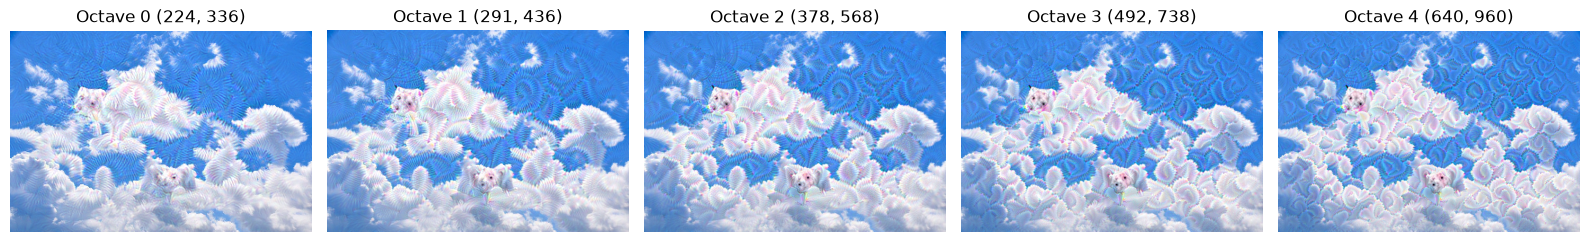

In [15]:
show_images(
    octave_images,
    [f"Octave {i} {tuple(o.shape[1:3])}" for i, o in enumerate(octave_images)],
)

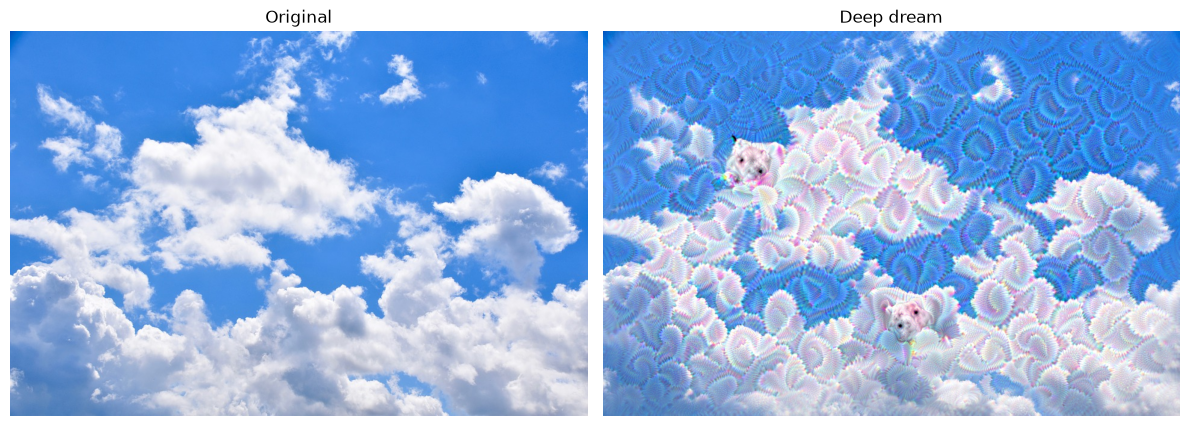

In [16]:
show_images([original_img, img], ["Original", "Deep dream"])

## Compare layers

Each layer of InceptionV3 responds to different features. Here we dream the same image with pairs of layers from low to high in the network. Each result is saved with its settings in the filename.

In [17]:
layer_experiments = [
    {"mixed2": 1.0, "mixed3": 1.0},
    {"mixed4": 1.0, "mixed5": 1.0},
    {"mixed6": 1.0, "mixed7": 1.0},
    {"mixed8": 1.0, "mixed9": 1.0},
]

results = []
for settings in layer_experiments:
    print("Layers:", ", ".join(settings))
    dream, _ = deep_dream(original_img, settings, **dream_settings)
    keras.utils.save_img(
        result_filename(image_name, settings, dream_settings), deprocess_image(dream)
    )
    results.append(dream)

Layers: mixed2, mixed3


Octave 0 (224, 336): 20 steps, loss 0.56 -> 2.08


Octave 1 (291, 436): 20 steps, loss 1.41 -> 2.92


Octave 2 (378, 568): 20 steps, loss 1.65 -> 3.13


Octave 3 (492, 738): 20 steps, loss 1.81 -> 3.54


...

Octave 0 (224, 336): 20 steps, loss 0.01 -> 0.54


Octave 1 (291, 436): 20 steps, loss 0.32 -> 0.86


Octave 2 (378, 568): 20 steps, loss 0.33 -> 1.15


Octave 3 (492, 738): 20 steps, loss 0.44 -> 1.27


Octave 4 (640, 960): 20 steps, loss 0.42 -> 1.48


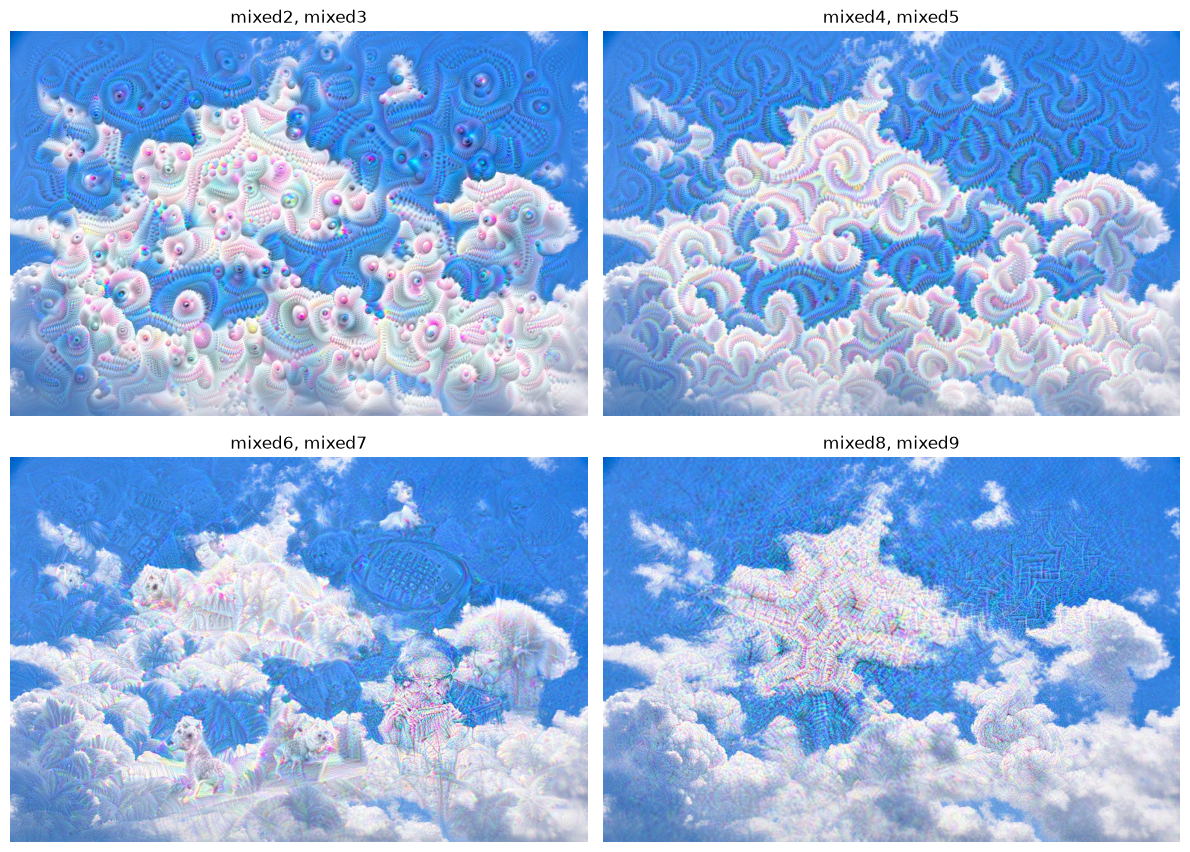

In [18]:
show_images(results, [", ".join(settings) for settings in layer_experiments], cols=2)

## Further reading

- The original [Keras Deep Dream example](https://keras.io/examples/generative/deep_dream/). You can use the trained model hosted on [Hugging Face Hub](https://huggingface.co/keras-io/deep-dream) and try the demo on [Hugging Face Spaces](https://huggingface.co/spaces/keras-io/deep-dream).
- TensorFlow's [DeepDream tutorial](https://www.tensorflow.org/tutorials/generative/deepdream), which uses random shifts and tiling to dream on large images.
- Deep Learning with Python, [Chapter 10: Interpreting what ConvNets learn](https://deeplearningwithpython.io/chapters/chapter10_interpreting-what-convnets-learn)
- Deep Learning with Python, [Chapter 17: Image generation](https://deeplearningwithpython.io/chapters/chapter17_image-generation)